In [10]:
import pandas as pd
from os import getcwd
import seaborn as sns
import matplotlib.pyplot as plt
from pennylane.workflow.interfaces import torch
from torch._inductor.codegen.cuda.cutlass_lib_extensions.cutlass_mock_imports.cuda import cuda

import random_forest_model
from TODO.zadanie1.michal.graph_mtl_utils import MTLHybridNet

# print(getcwd())

df = pd.read_parquet('./../../../dataset.parquet')
tasks = ['bioavailability_ma', 'hia_hou', 'pgp_broccatelli', 'bbb_martins',
 'cyp2c9_veith', 'cyp2d6_veith', 'cyp3a4_veith',
 'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels',
 'cyp3a4_substrate_carbonmangels', 'hERG_Karim', 'ames', 'dili']
df = df[df['task'].isin(tasks)]

df_wide = df.pivot_table(index='smiles', columns='task', values='label')

In [11]:
print(df['task'].value_counts())
avg_tasks = df.groupby('smiles')['task'].nunique().mean()
print(f"Średnia liczba zadań na smiles: {avg_tasks:.2f}")
presence_mask = df_wide.notna().astype(int)

overlap_matrix = presence_mask.T @ presence_mask

stats_df = df.groupby('task')['label'].agg(['mean', 'count', 'std']).reset_index()
overlap_matrix = overlap_matrix.merge(stats_df, on='task')
overlap_matrix.head()

task
hERG_Karim                        13445
cyp2d6_veith                      13130
cyp3a4_veith                      12328
cyp2c9_veith                      12092
ames                               7278
bbb_martins                        2030
pgp_broccatelli                    1218
cyp3a4_substrate_carbonmangels      670
cyp2c9_substrate_carbonmangels      669
cyp2d6_substrate_carbonmangels      667
bioavailability_ma                  640
hia_hou                             578
dili                                475
Name: count, dtype: int64
Średnia liczba zadań na smiles: 1.63


,task,ames,bbb_martins,bioavailability_ma,cyp2c9_substrate_carbonmangels,cyp2c9_veith,cyp2d6_substrate_carbonmangels,cyp2d6_veith,cyp3a4_substrate_carbonmangels,cyp3a4_veith,dili,hERG_Karim,hia_hou,pgp_broccatelli,mean,count,std
0,ames,7255,173,106,113,110,114,124,112,110,124,58,66,104,0.546029,7278,0.497911
1,bbb_martins,173,1975,293,216,114,217,114,216,104,135,133,90,111,0.764039,2030,0.424702
2,bioavailability_ma,106,293,640,203,81,204,92,202,85,114,141,129,93,0.768750,640,0.421962
3,cyp2c9_substrate_carbonmangels,113,216,203,666,113,660,112,661,103,70,127,127,112,0.210762,669,0.408155
4,cyp2c9_veith,110,114,81,113,12092,113,9750,114,9265,59,69,91,134,0.334519,12092,0.471841


In [17]:
# summary_df = random_forest_model.run_single_task_pipeline(df, tasks)


--- Top 15 najważniejszych cech dla ames ---
            feature  importance
   MaxPartialCharge    0.024060
MaxAbsPartialCharge    0.023162
                qed    0.021496
            MolLogP    0.020553
              MolWt    0.020257
           BalabanJ    0.019642
          LabuteASA    0.018981
              MolMR    0.018837
               TPSA    0.016987
       FractionCSP3    0.016748
NumValenceElectrons    0.016707
     HeavyAtomCount    0.014237
   NumAromaticRings    0.012239
            bit_725    0.011957
            NOCount    0.011718

--- Top 15 najważniejszych cech dla bbb_martins ---
            feature  importance
               TPSA    0.034997
         NumHDonors    0.032709
          NHOHCount    0.031067
            NOCount    0.027807
                qed    0.025374
MaxAbsPartialCharge    0.021953
      NumHAcceptors    0.019780
            MolLogP    0.017837
              MolWt    0.016160
              MolMR    0.015449
          LabuteASA    0.013541
NumVa

### MTL model

In [12]:
%load_ext autoreload
%autoreload 2
from graph_mtl_utils import *
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
epochs = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_tab, y, mask, tasks, splits, smiles_list = prepare_mtl_hybrid_data(df)

train_idx = splits == 'train'
val_idx = splits == 'valid'

train_loader = DataLoader(
    MTLHybridDataset(X_tab[train_idx], y[train_idx], mask[train_idx], [smiles_list[i] for i in np.where(train_idx)[0]]),
    batch_size=64, shuffle=True, collate_fn=collate_hybrid
)
val_loader = DataLoader(
    MTLHybridDataset(X_tab[val_idx], y[val_idx], mask[val_idx], [smiles_list[i] for i in np.where(val_idx)[0]]),
    batch_size=64, shuffle=False, collate_fn=collate_hybrid
)

model = MTLHybridNet(tab_dim=X_tab.shape[1], n_tasks=len(tasks), head_neurons=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_auc_avg': [],
    'val_aucs_per_task': {t: [] for t in tasks}
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Rozpoczynam trening hybrydowego MTL (GNN + MLP) na 13 zadaniach...
Epoch 1/20 | Loss: 0.4872 | Val Loss: 0.4570 | Avg AUC: 0.8071
Epoch 2/20 | Loss: 0.4067 | Val Loss: 0.4161 | Avg AUC: 0.8303
Epoch 3/20 | Loss: 0.3747 | Val Loss: 0.4610 | Avg AUC: 0.8277
Epoch 4/20 | Loss: 0.3453 | Val Loss: 0.4435 | Avg AUC: 0.8445
Epoch 5/20 | Loss: 0.3260 | Val Loss: 0.3982 | Avg AUC: 0.8469
Epoch 6/20 | Loss: 0.3033 | Val Loss: 0.4023 | Avg AUC: 0.8432
Epoch 7/20 | Loss: 0.2901 | Val Loss: 0.4133 | Avg AUC: 0.8300
Epoch 8/20 | Loss: 0.2683 | Val Loss: 0.4162 | Avg AUC: 0.8398
Epoch 9/20 | Loss: 0.2601 | Val Loss: 0.4357 | Avg AUC: 0.8380
Epoch 10/20 | Loss: 0.2417 | Val Loss: 0.4277 | Avg AUC: 0.8411
Epoch 11/20 | Loss: 0.2312 | Val Loss: 0.4244 | Avg AUC: 0.8352
Epoch 12/20 | Loss: 0.2225 | Val Loss: 0.4403 | Avg AUC: 0.8349
Epoch 13/20 | Loss: 0.2123 | Val Loss: 0.4517 | Avg AUC: 0.8309
Epoch 14/20 | Loss: 0.2047 | Val Loss: 0.4501 | Avg AUC: 0.8344
Epoch 15/20 | Loss: 0.1936 | Val Loss: 0.4357 

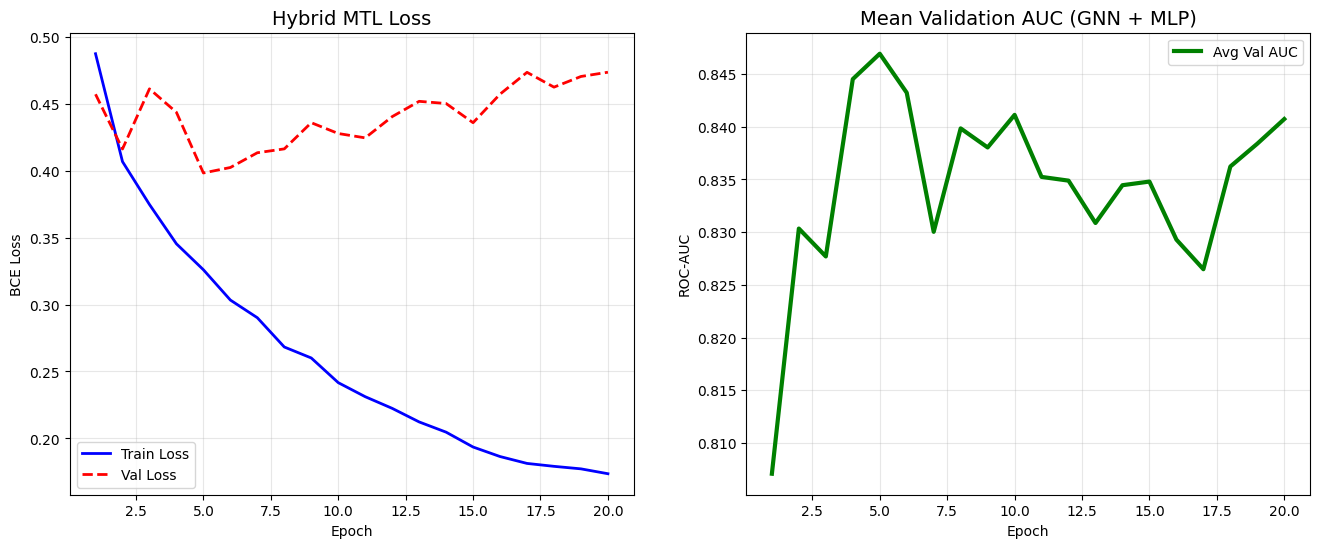

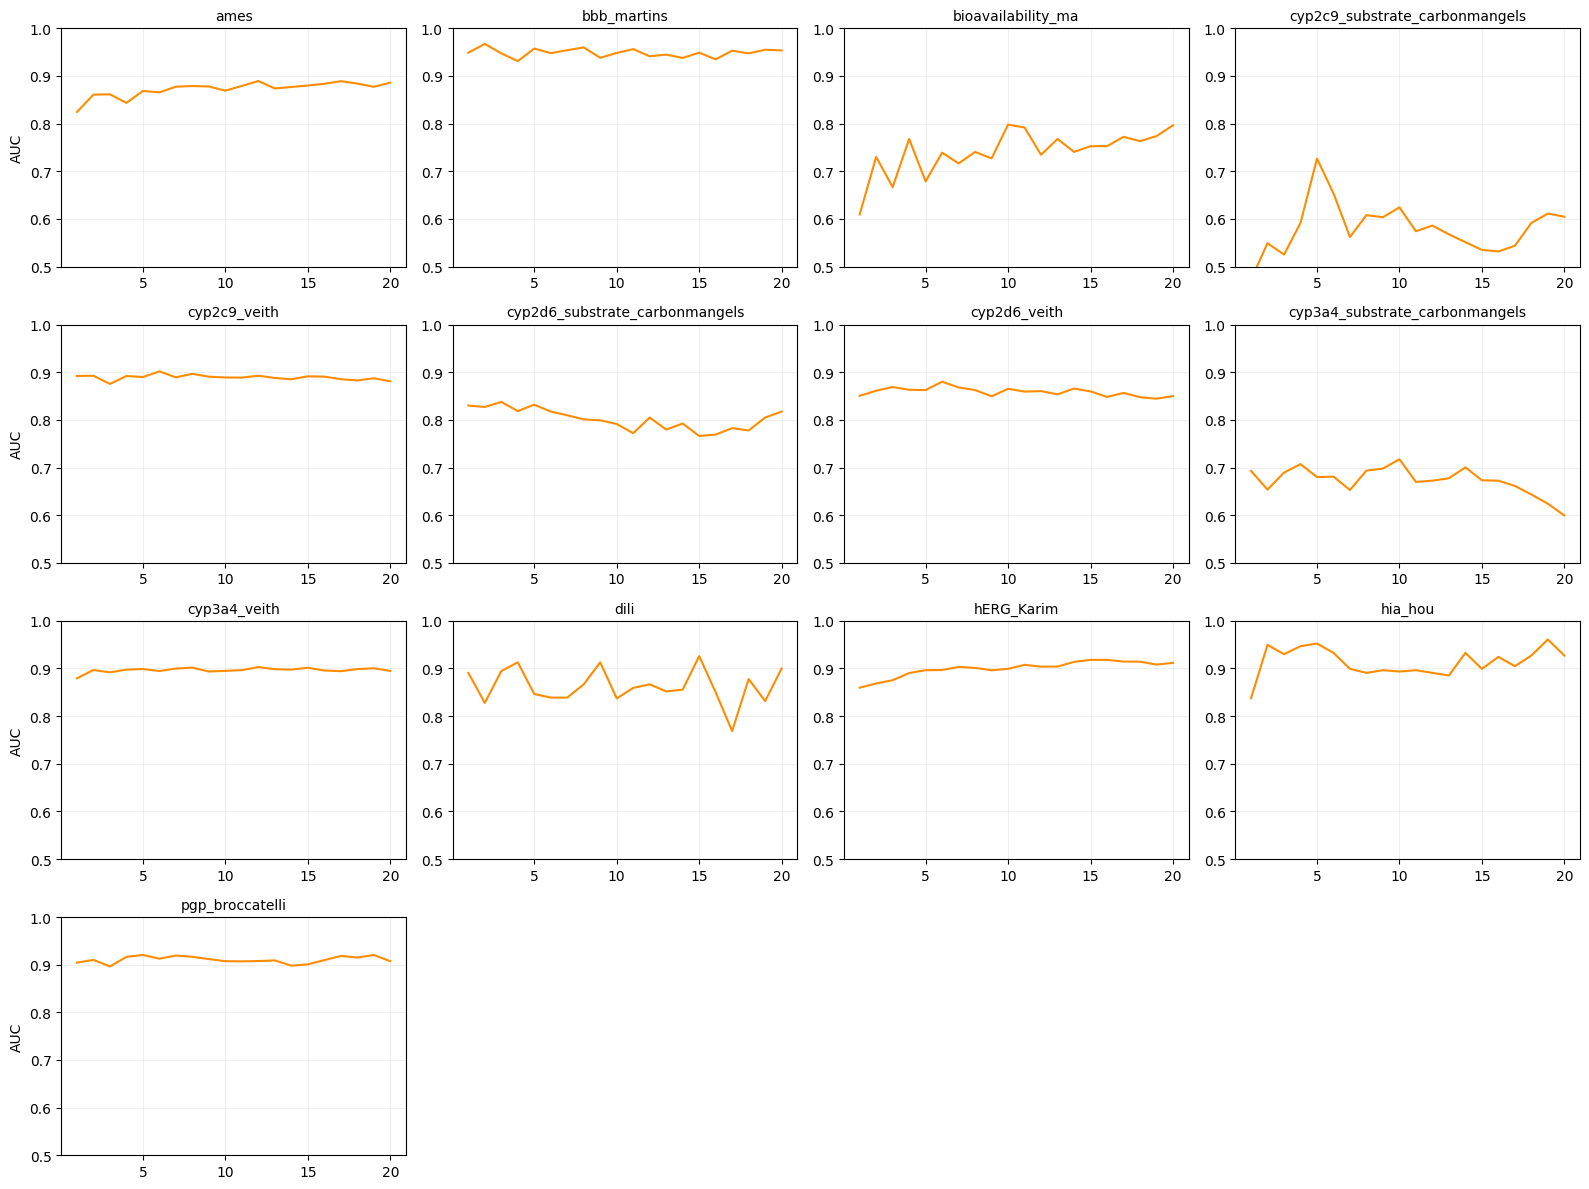

In [13]:
print(f"Rozpoczynam trening hybrydowego MTL (GNN + MLP) na {len(tasks)} zadaniach...")

for epoch in range(epochs):
    # TRENING
    model.train()
    epoch_train_loss = 0
    for batch_g, x_t, y_b, m_b in train_loader:
        batch_g, x_t, y_b, m_b = batch_g.to(device), x_t.to(device), y_b.to(device), m_b.to(device)

        optimizer.zero_grad()
        logits = model(batch_g, x_t)
        loss = F.binary_cross_entropy_with_logits(logits, y_b, reduction='none')
        loss = (loss * m_b).sum() / (m_b.sum() + 1e-8)

        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    # EVALUACJA
    model.eval()
    epoch_val_loss = 0
    all_preds, all_targets, all_masks = [], [], []

    with torch.no_grad():
        for batch_g, x_t, y_b, m_b in val_loader:
            batch_g, x_t, y_b, m_b = batch_g.to(device), x_t.to(device), y_b.to(device), m_b.to(device)
            logits = model(batch_g, x_t)

            v_loss = F.binary_cross_entropy_with_logits(logits, y_b, reduction='none')
            epoch_val_loss += ((v_loss * m_b).sum() / (m_b.sum() + 1e-8)).item()

            all_preds.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(y_b.cpu().numpy())
            all_masks.append(m_b.cpu().numpy())

    # Obliczanie AUC per task
    preds = np.vstack(all_preds)
    targets = np.vstack(all_targets)
    masks = np.vstack(all_masks)

    current_aucs = {}
    for i, t in enumerate(tasks):
        m = masks[:, i] == 1
        if m.sum() > 0 and len(np.unique(targets[m, i])) > 1:
            auc = roc_auc_score(targets[m, i], preds[m, i])
        else:
            auc = np.nan
        current_aucs[t] = auc
        history['val_aucs_per_task'][t].append(auc)

    avg_auc = np.nanmean(list(current_aucs.values()))
    history['train_loss'].append(epoch_train_loss / len(train_loader))
    history['val_loss'].append(epoch_val_loss / len(val_loader))
    history['val_auc_avg'].append(avg_auc)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f} | Avg AUC: {avg_auc:.4f}")
plot_hybrid_mtl_training(history, tasks)

## Porównanie wyników

In [14]:
# history

{'train_loss': [0.48723811108499904,
  0.4066869446744113,
  0.37467754169550116,
  0.3453175938905102,
  0.3259516711852866,
  0.3033413638671239,
  0.29013300486351257,
  0.26828083457195595,
  0.260084294190962,
  0.24167282658216616,
  0.23118274322111312,
  0.22247669930871763,
  0.21233880972345126,
  0.20469904534484698,
  0.19360919426020967,
  0.1865005950064964,
  0.18136595179365106,
  0.17918643117223157,
  0.17730778062792674,
  0.17367404146485677],
 'val_loss': [0.4569802885017698,
  0.416094113910009,
  0.4610100927807036,
  0.443481019328511,
  0.3982051830916178,
  0.40229750365491895,
  0.413304136149467,
  0.41619370688521673,
  0.4357442718649667,
  0.42767186356442316,
  0.42442119192509425,
  0.4402670209843015,
  0.4516976253380851,
  0.45005173129694803,
  0.43573798097315286,
  0.4570635961634772,
  0.47334488942509606,
  0.4622838402551318,
  0.4702456245819728,
  0.4734241592269095],
 'val_auc_avg': [np.float64(0.8070793489759792),
  np.float64(0.83033579217

In [37]:
import pandas as pd
import numpy as np

# 1. Szukamy epoki, w której GNN pokonuje SOTA na największej ilości tasków
best_epoch_idx = 0
max_wins = -1

for epoch in range(len(history['train_loss'])):
    wins_in_epoch = 0
    for task in tasks:
        gnn_auc = history['val_aucs_per_task'][task][epoch]
        sota_auc = SOTA_SCORES.get(task, 2.0) # 2.0 jako fallback, by nie wygrywać z brakiem danych
        if gnn_auc > sota_auc:
            wins_in_epoch += 1

    if wins_in_epoch >= max_wins:
        max_wins = wins_in_epoch
        best_epoch_idx = epoch

print(f"Najlepsza epoka: {best_epoch_idx + 1} (Pokonano SOTA na {max_wins} zadaniach)")

# 2. Budujemy tabelę dla tej konkretnej epoki
df_rows_best = []
for task in tasks:
    row = {'Task': task}
    row['GNN'] = history['val_aucs_per_task'][task][best_epoch_idx]

    val = summary_df.loc[summary_df['task'] == task, 'auc']
    # row['Random_Forest'] = val.values[0] if not val.empty else np.nan
    row['SOTA'] = SOTA_SCORES.get(task, np.nan)
    df_rows_best.append(row)

# 3. DataFrame i wyświetlanie
df_best_val = pd.DataFrame(df_rows_best).set_index('Task')

display(
    df_best_val.style
    .format("{:.4f}")
    .highlight_max(axis=1, color='green')
)

Najlepsza epoka: 15 (Pokonano SOTA na 9 zadaniach)


,GNN,SOTA
Task,,
ames,0.8800,0.9180
bbb_martins,0.9489,0.9160
bioavailability_ma,0.7526,0.7480
cyp2c9_substrate_carbonmangels,0.5349,0.4410
cyp2c9_veith,0.8914,0.8590
cyp2d6_substrate_carbonmangels,0.7662,0.7360
cyp2d6_veith,0.8598,0.7900
cyp3a4_substrate_carbonmangels,0.6732,0.6620
cyp3a4_veith,0.9015,0.9160


In [38]:
# Generujesz kod HTML ze stylu
html_output = df_best_val.style.format("{:.4f}").highlight_max(axis=1, color='green').to_html()

# Zapisujesz do pliku
with open("./gnn_vs_SOTA.html", "w") as f:
    f.write(html_output)